# Lección 4: REDES NEURONALES CONVOLUTIVAS
## A. Rediseñar la arquitectura utilizando CNN

En la lección anterior implementamos una CNN funcional pero básica. Para mejorar significativamente la capacidad predictiva del modelo frente a imágenes más complejas, necesitamos rediseñar la arquitectura aumentando su profundidad y estabilidad.

En este nuevo diseño introduciremos:
1. **Un tercer bloque convolucional:** Para extraer características de un nivel más abstracto (bordes -> texturas -> partes de objetos).
2. **Batch Normalization (Normalización por Lotes):** Una capa fundamental en arquitecturas modernas que estandariza los datos *dentro* de la red oculta. Esto estabiliza el entrenamiento, permite usar tasas de aprendizaje más altas y actúa como un ligero regularizador.
3. **Padding 'same':** Para evitar que las convoluciones reduzcan el tamaño de la imagen en los bordes perdiendo información periférica.

In [18]:
# ── CELDA DE CARGA DE DATOS (ejecutar siempre primero) ───────────────────────
# Esta celda carga y prepara el dataset. Todas las celdas de esta lección
# dependen de las variables aquí definidas.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Cargar y normalizar Fashion-MNIST
(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()
train_images = train_images / 255.0
test_images  = test_images  / 255.0

print(f"✅ Datos cargados: Train {train_images.shape} | Test {test_images.shape}")

# ── Hiperparámetros centralizados ─────────────────────────────────────────────
NUM_CLASSES   = 10
INPUT_SHAPE   = (28, 28)
DROPOUT_RATE  = 0.5
LEARNING_RATE = 0.001

NOMBRES_CLASES = ['Camiseta', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
                  'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

✅ Datos cargados: Train (60000, 28, 28) | Test (10000, 28, 28)


In [19]:
# ── A. Construcción de la CNN avanzada ────────────────────────────────────────

def build_cnn(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES, dropout_rate=DROPOUT_RATE):
    """
    CNN profunda para clasificación de imágenes Fashion-MNIST.
    Arquitectura: 3 bloques Conv→BN→ReLU→Pool + cabeza clasificadora densa.
    """
    model = models.Sequential([
        # Entrada: adaptar forma (28,28) → (28,28,1)
        layers.Input(shape=input_shape),
        layers.Reshape((*input_shape, 1)),

        # ── Bloque 1: características de bajo nivel ──
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # ── Bloque 2: características de nivel medio ──
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # ── Bloque 3: características de alto nivel ──
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),

        # ── Clasificador ──
        layers.Flatten(),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax'),
    ], name='CNN_FashionMNIST')

    return model

# ── Compilación ───────────────────────────────────────────────────────────────
model_cnn_avanzada = build_cnn()
model_cnn_avanzada.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("─── Resumen de la Nueva Arquitectura CNN ───")
model_cnn_avanzada.summary()

─── Resumen de la Nueva Arquitectura CNN ───
Model: "CNN_FashionMNIST"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_4 (Reshape)         (None, 28, 28, 1)         0         
                                                                 
 conv2d_12 (Conv2D)          (None, 28, 28, 32)        320       
                                                                 
 batch_normalization_16 (Bat  (None, 28, 28, 32)       128       
 chNormalization)                                                
                                                                 
 activation_16 (Activation)  (None, 28, 28, 32)        0         
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 14, 14, 32)       0         
 g2D)                                                            
                                                                 
 conv

### Análisis del rediseño

* **Mayor Capacidad de Representación:** Al pasar de 64 a 128 filtros en la última etapa convolucional, le estamos dando al modelo "más espacio de memoria" para reconocer un abanico más amplio de patrones complejos antes de tomar la decisión final.
* **El efecto de Batch Normalization:** Si entrenamos este modelo, notaremos que alcanza precisiones altas mucho más rápido (en menos épocas) que el modelo de la Lección 3. Al normalizar los datos internamente, evitamos que los pesos se desajusten abruptamente.
* **Aumento de Parámetros:** El `summary()` nos mostrará un incremento en los parámetros totales entrenables. Es el costo a pagar por un modelo más inteligente: requiere más poder de cómputo, justificando aún más el uso del *Dropout* para que la red no memorice la ropa de entrenamiento.

## B. Evaluar y comparar los resultados con el modelo anterior

Para saber si nuestro rediseño realmente valió la pena, no basta con mirar la precisión general (Accuracy). En problemas de clasificación, utilizamos métricas avanzadas para entender exactamente en qué categorías se equivoca el modelo:

* **Precision (Precisión):** De todas las imágenes que el modelo etiquetó como "Camiseta", ¿cuántas eran realmente camisetas? Mide la calidad de la predicción y los falsos positivos.
* **Recall (Sensibilidad):** De todas las camisetas reales que hay en las fotos, ¿cuántas logró encontrar el modelo? Mide la cantidad detectada y los falsos negativos.
* **F1-Score:** Es un promedio armónico entre Precision y Recall. Es la métrica ideal para evaluar el modelo de forma equilibrada.

Vamos a entrenar nuestra nueva CNN y generaremos un reporte detallado usando `scikit-learn` para ver dónde están sus puntos débiles.

Entrenando la CNN Avanzada...
Epoch 1/5
375/375 [==============================] - 22s 57ms/step - loss: 0.4530 - accuracy: 0.8401 - val_loss: 1.1686 - val_accuracy: 0.6259
Epoch 2/5
375/375 [==============================] - 22s 58ms/step - loss: 0.2896 - accuracy: 0.8956 - val_loss: 0.2930 - val_accuracy: 0.8915
Epoch 3/5
375/375 [==============================] - 22s 59ms/step - loss: 0.2407 - accuracy: 0.9127 - val_loss: 0.2860 - val_accuracy: 0.8968
Epoch 4/5
375/375 [==============================] - 21s 57ms/step - loss: 0.2143 - accuracy: 0.9225 - val_loss: 0.2923 - val_accuracy: 0.8969
Epoch 5/5
375/375 [==============================] - 22s 58ms/step - loss: 0.1856 - accuracy: 0.9319 - val_loss: 0.4002 - val_accuracy: 0.8478

✅ Precisión en Test: 0.8414

─── Reporte de Clasificación ───
              precision    recall  f1-score   support

    Camiseta       0.96      0.48      0.64      1000
    Pantalón       0.99      0.98      0.99      1000
      Suéter       0.97      

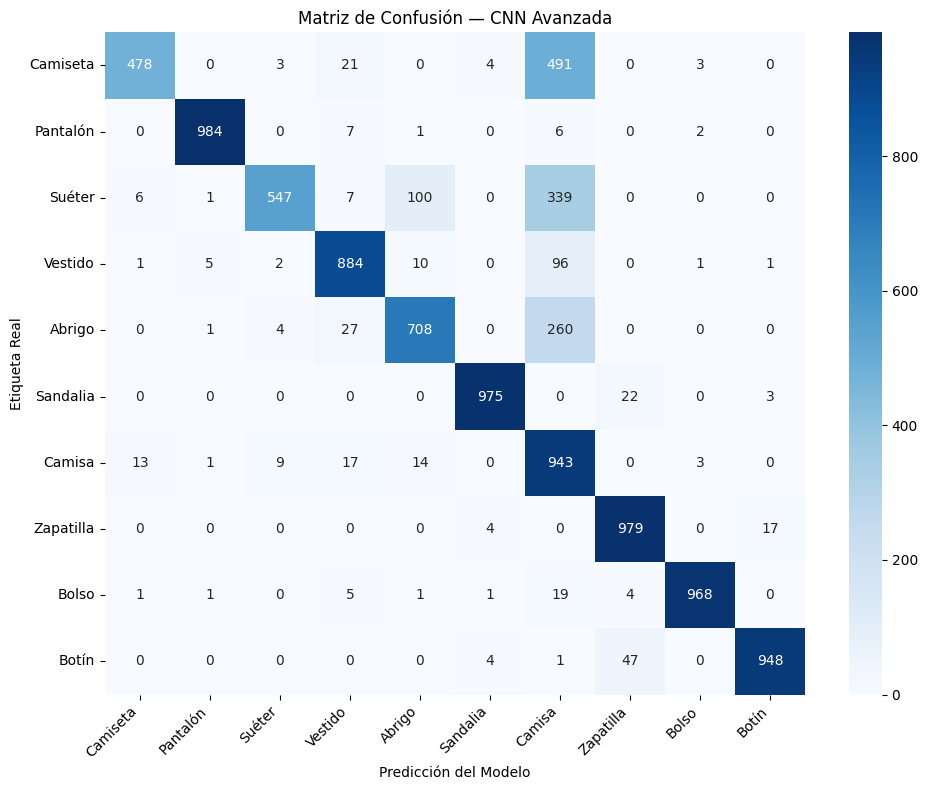

In [20]:
# ── B. Entrenamiento + evaluación de la CNN avanzada ─────────────────────────
# NOTA: Requiere haber ejecutado la celda de carga de datos y la celda A.

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ── Entrenamiento ─────────────────────────────────────────────────────────────
print("Entrenando la CNN Avanzada...")
hist_avanzada = model_cnn_avanzada.fit(
    train_images, train_labels,
    epochs=5,
    batch_size=128,          # Batch más grande para acelerar el entrenamiento
    validation_split=0.2,
    verbose=1
)

# ── Evaluación ────────────────────────────────────────────────────────────────
loss_avanzada, acc_avanzada = model_cnn_avanzada.evaluate(test_images, test_labels, verbose=0)
print(f"\n✅ Precisión en Test: {acc_avanzada:.4f}")

# ── Reporte detallado por clase ───────────────────────────────────────────────
predicciones = np.argmax(model_cnn_avanzada.predict(test_images, verbose=0), axis=1)
print("\n─── Reporte de Clasificación ───")
print(classification_report(test_labels, predicciones, target_names=NOMBRES_CLASES))

# ── Matriz de Confusión ───────────────────────────────────────────────────────
cm = confusion_matrix(test_labels, predicciones)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=NOMBRES_CLASES, yticklabels=NOMBRES_CLASES)
plt.title('Matriz de Confusión — CNN Avanzada')
plt.ylabel('Etiqueta Real')
plt.xlabel('Predicción del Modelo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Análisis de los resultados

* **Interpretación del F1-Score:** Las categorías con F1 más bajo (generalmente Camiseta vs. Camisa, o Suéter vs. Abrigo) revelan las confusiones visuales más comunes para el modelo, lo cual es esperable dado que comparten siluetas similares.
* **Matriz de Confusión:** Los valores fuera de la diagonal principal son los errores. Si notamos una celda muy marcada entre dos clases, significa que el modelo las confunde frecuentemente y podría requerir más datos o técnicas de aumento de datos.
* **Comparativa con Lección 3:** Con BatchNormalization y 3 bloques convolucionales, la CNN avanzada debería superar al modelo base de la Lección 3 en precisión general.

## C. Predicción con imagen externa

La prueba definitiva de un clasificador es someterlo a imágenes del mundo real que nunca ha visto. Descargaremos una imagen de internet, la preprocesaremos para que tenga el mismo formato que Fashion-MNIST (28×28 píxeles, escala de grises, fondo negro), y observaremos cómo el modelo distribuye su confianza entre las 10 categorías.

**Usaremos `model_cnn_avanzada`**, el modelo más completo de este proyecto, para la predicción final.

Procesando imágenes y generando predicciones...



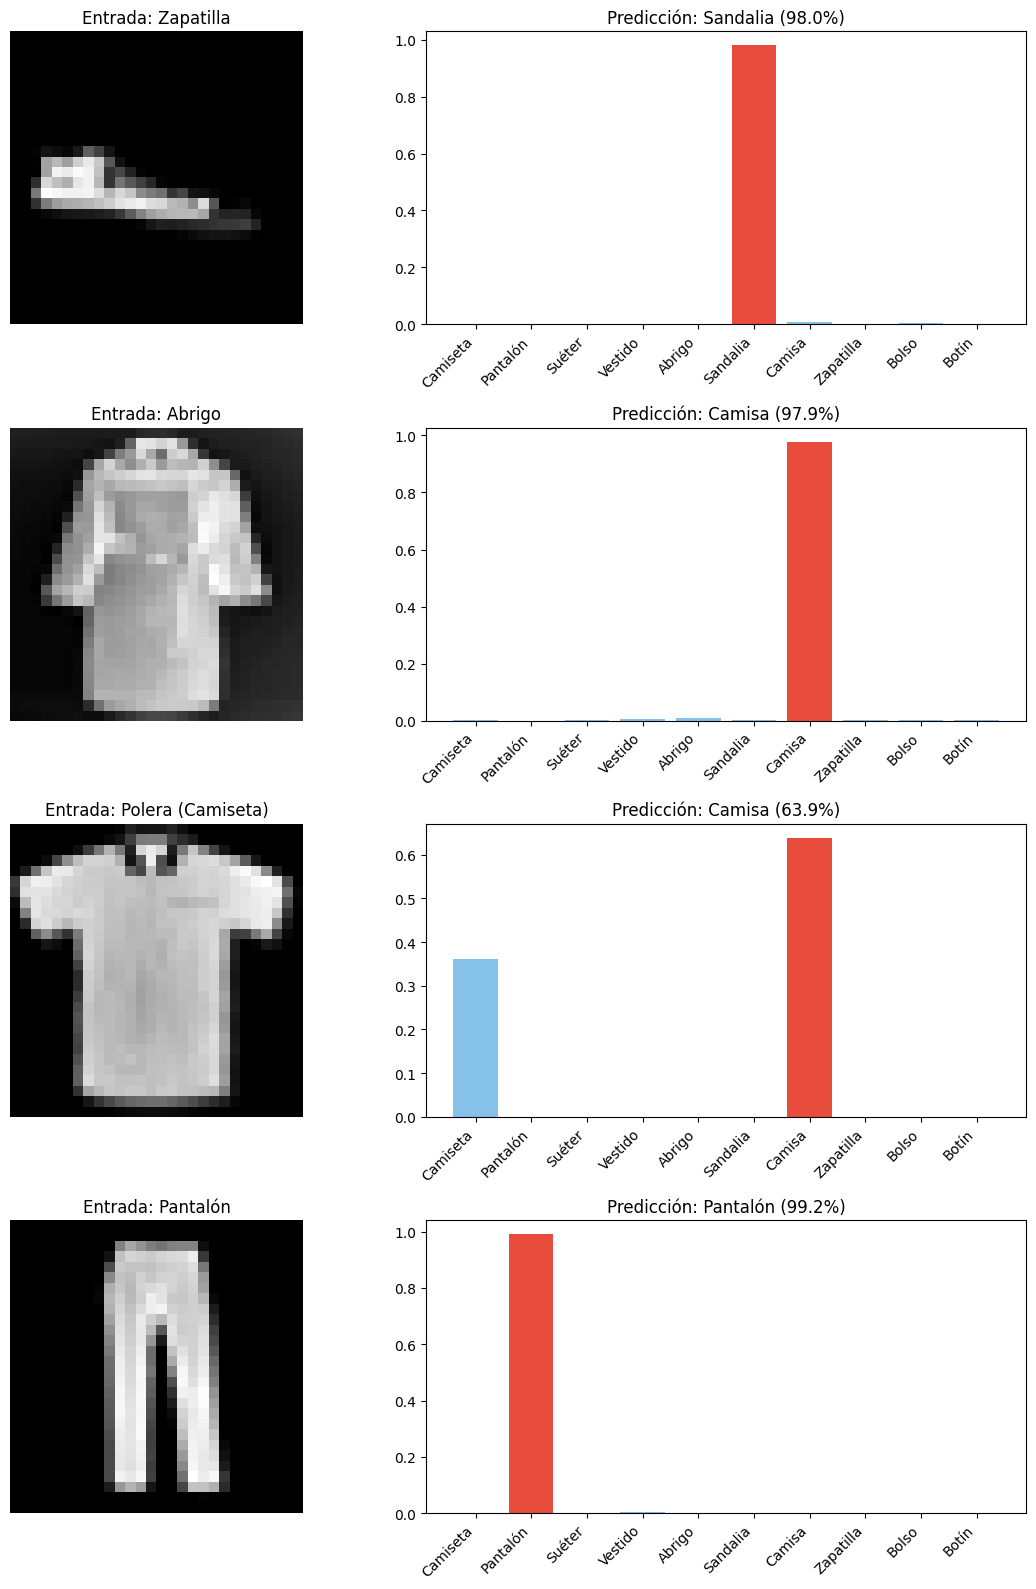

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import requests
from io import BytesIO

# 1. Diccionario con nuestras imágenes de prueba
headers = {'User-Agent': 'Mozilla/5.0'}
imagenes_prueba = {
    "Zapatilla": "https://cdn.pixabay.com/photo/2013/07/12/18/20/shoes-153310_960_720.png",
    "Abrigo": "https://lubymaria.cl/wp-content/uploads/2022/02/abrigo-camel-mujer-gris-6.webp",
    "Polera (Camiseta)": "https://cdn.pixabay.com/photo/2013/07/13/14/07/apparel-162180_960_720.png",
    "Pantalón": "https://tworldstore.cl/5463-large_default/pantalon-classic-mujer-65-poly-35-alg.jpg"
}

NOMBRES_CLASES = ['Camiseta', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
                  'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Botín']

fig, axes = plt.subplots(4, 2, figsize=(12, 16))

print("Procesando imágenes y generando predicciones...\n")

for i, (nombre_real, url) in enumerate(imagenes_prueba.items()):
    
    # --- Descarga ---
    respuesta = requests.get(url, headers=headers)
    img_original = Image.open(BytesIO(respuesta.content))
    
    # --- Preprocesamiento CORREGIDO para fondos transparentes ---
    # Convertimos a RGBA, pegamos sobre fondo blanco y luego pasamos a grises
    img_rgba = img_original.convert("RGBA")
    lienzo_blanco = Image.new("RGBA", img_rgba.size, "WHITE")
    lienzo_blanco.paste(img_rgba, (0, 0), img_rgba)
    
    img_gris = lienzo_blanco.convert('L')
    img_invertida = ImageOps.invert(img_gris)
    img_redimensionada = img_invertida.resize((28, 28))
    
    img_array = np.array(img_redimensionada) / 255.0
    img_lote = np.expand_dims(img_array, axis=0)
    
    # --- Predicción ---
    prediccion_prob = model_cnn_avanzada.predict(img_lote, verbose=0)
    clase_ganadora = np.argmax(prediccion_prob)
    confianza = np.max(prediccion_prob) * 100
    
    # --- Gráficos ---
    ax_img = axes[i, 0]
    ax_img.imshow(img_array, cmap='gray')
    ax_img.set_title(f"Entrada: {nombre_real}")
    ax_img.axis('off')
    
    ax_bar = axes[i, 1]
    colores = ['#e74c3c' if j == clase_ganadora else '#85c1e9' for j in range(10)]
    ax_bar.bar(NOMBRES_CLASES, prediccion_prob[0], color=colores)
    ax_bar.set_xticks(range(10))
    ax_bar.set_xticklabels(NOMBRES_CLASES, rotation=45, ha='right')
    ax_bar.set_title(f"Predicción: {NOMBRES_CLASES[clase_ganadora]} ({confianza:.1f}%)")

plt.tight_layout()
plt.show()